# 02 — Normalization, highly variable genes, PCA, batch effects, clustering, UMAP

This is the core "get from raw counts to clusters" pipeline. We'll build it
up step by step, and along the way you'll see — with your own eyes, in a
plot — exactly why "batch effects" and "integration" are such a big deal in
single-cell analysis.

## Concepts before code

**Normalization.** Different nuclei have different total UMI counts, purely
for technical reasons (capture efficiency, sequencing depth) — not because
one nucleus "really" makes 3x more RNA than another. `sc.pp.normalize_total`
rescales each nucleus's counts so they sum to the same target total (we'll
use 10,000, a common convention — "counts per 10k"), removing that
depth-driven variation before we compare gene expression *between* nuclei.

**Log transform.** Count data is highly right-skewed (a few genes with huge
counts, most genes with 0-few). `sc.pp.log1p` (i.e. `log(x + 1)`) compresses
that range, makes the data closer to normally-distributed (which many
downstream methods, like PCA, implicitly assume), and turns fold-changes
into additive differences.

**Highly variable genes (HVGs).** Most of the ~36,600 genes are either not
expressed or vary only due to noise. Clustering/PCA on all of them mostly
adds noise dimensions. We instead select a subset (here, 2,000) of genes
whose expression varies *more than expected* given their mean expression —
these are the genes actually carrying cell-type signal — and restrict
downstream analysis to them.

**Scaling.** Before PCA, we z-score each gene (mean 0, unit variance,
clipped to avoid extreme outliers dominating) so that highly-expressed
genes don't automatically dominate the principal components just because
their raw values are numerically larger.

**PCA.** Standard dimensionality reduction — same PCA you already know from
general ML. We compress ~2,000 HVGs down to ~30-50 principal components
that capture most of the biologically meaningful variance, which makes
every downstream step (neighbor graphs, clustering, UMAP) faster and less
noisy.

**The batch effect problem.** We have 8 different donors, each prepped and
sequenced somewhat independently. Even after normalization, donors can
differ systematically in ways that have nothing to do with cell type —
reagent lot, exact processing day, subtle capture efficiency differences.
If we don't do anything about this, PCA/UMAP can partly separate nuclei *by
donor* rather than purely *by cell type*, which would be a confound, not
biology. We'll show this directly below, then correct for it with
**Harmony**, an integration algorithm that adjusts the PCA embedding to
mix donors together while preserving cell-type structure.

**Leiden clustering.** A graph-based community-detection algorithm: build a
k-nearest-neighbor graph of nuclei in PCA space, then partition that graph
into densely-connected communities ("clusters"). This is the standard
clustering approach in single-cell analysis — no assumption of
spherical/Gaussian clusters, unlike k-means.

**UMAP.** A nonlinear 2D embedding used purely for *visualization* — it
preserves local neighborhood structure well but distances between distant
clusters aren't quantitatively meaningful. We cluster in PCA space and only
use UMAP to *look at* the result.

In [1]:
import warnings
import gc

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100
np.random.seed(0)

DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
RNA_DIR = f"{DATA_DIR}/rna"
PROCESSED_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-python-scanpy/data/processed"

DONOR_IDS = [
    "H20.33.001", "H20.33.002", "H20.33.004", "H20.33.005",
    "H20.33.012", "H20.33.013", "H20.33.017", "H21.33.003",
]

# Same QC thresholds justified and applied in notebook 01.
MIN_COUNTS = 500
MIN_GENES = 250
MAX_PCT_MT = 5.0
MAX_DOUBLET = 0.3

## Load, QC-filter, and combine all 8 donors

We reload each donor from raw counts, apply the same filter from notebook
01, strip out columns/layers we don't need (to keep memory down), and
concatenate into one combined AnnData with a `donor` column marking origin
— one donor at a time, released before the next, same pattern as notebook 01.

In [2]:
adatas = []

for donor in DONOR_IDS:
    a = sc.read_h5ad(f"{RNA_DIR}/{donor}_RNAseq_final-nuclei.h5ad")
    a.X = a.layers["UMIs"].copy()
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

    keep = (
        (a.obs["total_counts"] >= MIN_COUNTS)
        & (a.obs["n_genes_by_counts"] >= MIN_GENES)
        & (a.obs["pct_counts_mt"] <= MAX_PCT_MT)
        & (a.obs["Doublet score"] <= MAX_DOUBLET)
    )
    a = a[keep].copy()

    # Keep only the obs columns we'll actually use downstream, to save memory
    # once we concatenate 8 donors together.
    keep_cols = [
        "total_counts", "n_genes_by_counts", "pct_counts_mt", "Doublet score",
        "method", "Class", "Subclass", "Supertype",
        "Overall AD neuropathological Change", "Braak", "Donor ID",
    ]
    a.obs = a.obs[keep_cols].copy()
    a.obs["donor"] = donor
    a.layers.clear()
    a.obsm.clear()
    a.uns.clear()

    adatas.append(a)
    print(f"{donor}: {a.n_obs:,} nuclei retained after QC filtering")

adata = ad.concat(adatas, join="inner", label="batch", index_unique="-")
adata.obs_names_make_unique()
del adatas
gc.collect()

print(f"\nCombined dataset: {adata.n_obs:,} nuclei x {adata.n_vars:,} genes")

H20.33.001: 19,160 nuclei retained after QC filtering


H20.33.002: 19,548 nuclei retained after QC filtering


H20.33.004: 20,297 nuclei retained after QC filtering


H20.33.005: 25,425 nuclei retained after QC filtering


H20.33.012: 16,357 nuclei retained after QC filtering


H20.33.013: 18,149 nuclei retained after QC filtering


H20.33.017: 14,420 nuclei retained after QC filtering


H21.33.003: 18,856 nuclei retained after QC filtering



Combined dataset: 152,212 nuclei x 36,601 genes


## Normalize, log-transform, and select highly variable genes

In [3]:
# Cast to float32 early: raw counts and log-normalized values don't need
# float64 precision, and halving matrix memory matters once we keep both a
# raw-counts layer AND a full-gene-set .raw copy around (see below) for a
# combined dataset this size.
adata.X = adata.X.astype(np.float32)
adata.layers["counts"] = adata.X.copy()  # keep raw counts alongside for later notebooks

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# batch_key='donor' asks scanpy to select genes variable *within* each donor
# and combine the ranking, so we don't just pick genes that vary because they
# separate donors.
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor")

print(f"HVGs selected: {adata.var['highly_variable'].sum()} / {adata.n_vars}")

HVGs selected: 2000 / 36601


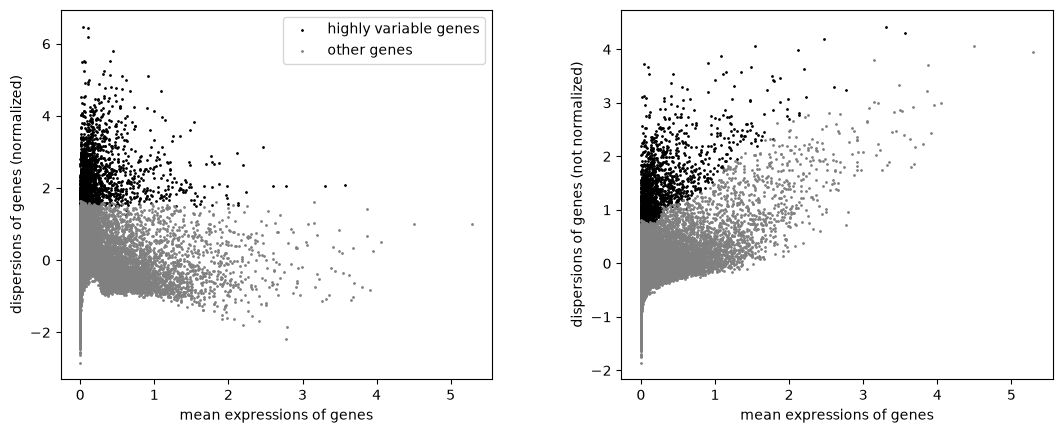

In [4]:
sc.pl.highly_variable_genes(adata)

Restrict to HVGs for scaling/PCA (this is the standard scanpy convention —
`.raw` keeps the full log-normalized matrix around in case we want it
later, e.g. for marker gene lookups in notebook 03 on genes that weren't
selected as HVGs).

In [5]:
adata.raw = adata  # stash full gene set (log-normalized) before subsetting
adata = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata, max_value=10)

## PCA — and seeing the batch effect directly

In [6]:
sc.tl.pca(adata, n_comps=30, svd_solver="arpack")

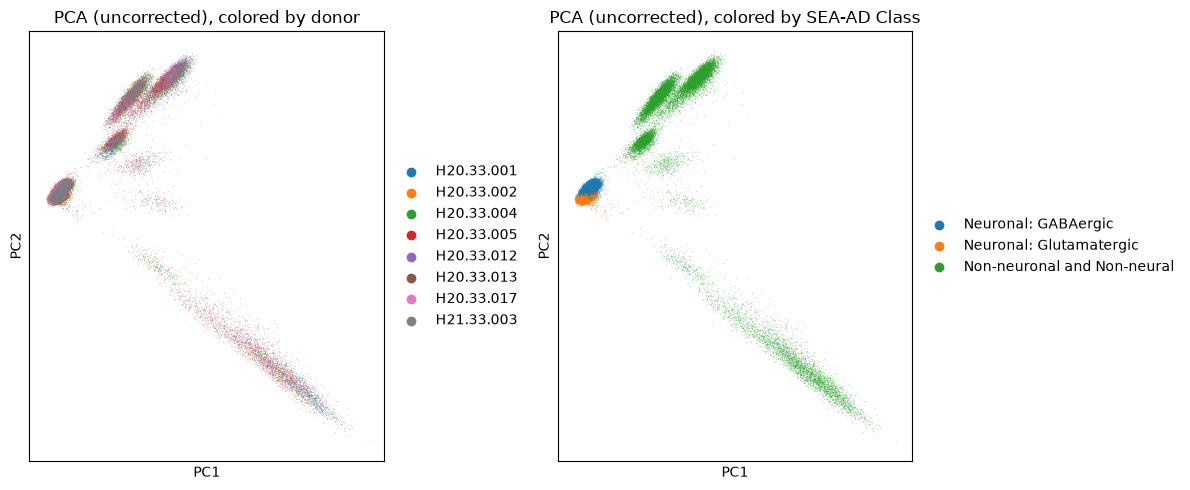

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.pca(adata, color="donor", ax=axes[0], show=False, title="PCA (uncorrected), colored by donor")
sc.pl.pca(adata, color="Class", ax=axes[1], show=False, title="PCA (uncorrected), colored by SEA-AD Class")
plt.tight_layout()
plt.show()

Look closely at the left panel. If donors were purely mixed by biology, you
would *not* expect to see them separate into distinct sub-blobs — cell
types are broadly shared across donors (everyone has astrocytes,
excitatory neurons, etc). Any visible donor-colored structure beyond what's
explained by `Class` on the right is (at least partly) a **technical batch
effect** we need to correct before trusting our own clustering. This is the
central motivation for integration.

## Batch correction with Harmony

[Harmony](https://github.com/immunogenomics/harmony) iteratively adjusts
the PCA embedding so that nuclei cluster by shared biological signal rather
than by donor of origin, without touching the actual gene expression
values — it works purely in PC space, producing a corrected embedding
(`X_pca_harmony`) we use downstream instead of raw `X_pca`.

In [8]:
# NOTE: sc.external.pp.harmony_integrate() has a known shape-mismatch bug
# against harmonypy>=1.0 (its C++-backend rewrite changed the orientation of
# the corrected embedding it returns, from PCs x cells to cells x PCs, which
# scanpy's wrapper doesn't account for as of scanpy 1.11.5). This is a good
# example of ordinary dependency-version friction in a real environment —
# rather than pin an older harmonypy, we call harmonypy directly and store
# the result ourselves.
import harmonypy

ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, "donor")
adata.obsm["X_pca_harmony"] = ho.Z_corr.astype(np.float32)  # already (n_cells, n_pcs) in harmonypy>=1.0

2026-08-19 12:52:47,647 - harmonypy - INFO - Running Harmony


2026-08-19 12:52:47,649 - harmonypy - INFO -   Parameters:


2026-08-19 12:52:47,649 - harmonypy - INFO -     max_iter_harmony: 10


2026-08-19 12:52:47,649 - harmonypy - INFO -     max_iter_kmeans: 4


2026-08-19 12:52:47,649 - harmonypy - INFO -     epsilon_cluster: 0.001


...

2026-08-19 12:52:51,075 - harmonypy - INFO - Iteration 2 of 10


2026-08-19 12:52:52,760 - harmonypy - INFO - Iteration 3 of 10


2026-08-19 12:52:54,464 - harmonypy - INFO - Iteration 4 of 10


2026-08-19 12:52:56,172 - harmonypy - INFO - Iteration 5 of 10


2026-08-19 12:52:57,880 - harmonypy - INFO - Converged after 5 iterations


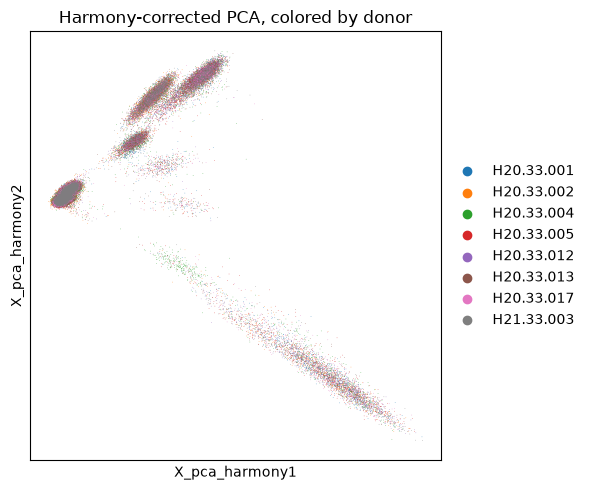

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
sc.pl.embedding(adata, basis="X_pca_harmony", color="donor", ax=ax, show=False,
                 title="Harmony-corrected PCA, colored by donor")
plt.tight_layout()
plt.show()

Donors should now mix much more evenly across the embedding compared to
the uncorrected PCA above — that's Harmony doing its job.

## Neighbor graph, Leiden clustering, UMAP

We build the k-nearest-neighbor graph on the **Harmony-corrected**
components (`use_rep="X_pca_harmony"`), then cluster that graph with
Leiden, then compute UMAP from the same graph purely for visualization.

In [10]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca_harmony")
sc.tl.leiden(adata, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
sc.tl.umap(adata)

print(f"Number of Leiden clusters found: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts().sort_index())

Number of Leiden clusters found: 35
leiden
0      3512
1      4065
2      7345
3      2727
4      6369
5      2090
6      5867
7      4966
8     12802
9     15169
10     8342
11     1871
12     7330
13     5014
14     9019
15     2908
16     1518
17     1870
18     2441
19     9045
20     7295
21     1412
22     2000
23     4314
24     2401
25     7241
26     3764
27     2434
28      486
29     3638
30     1229
31     1125
32      112
33      209
34      282
Name: count, dtype: int64


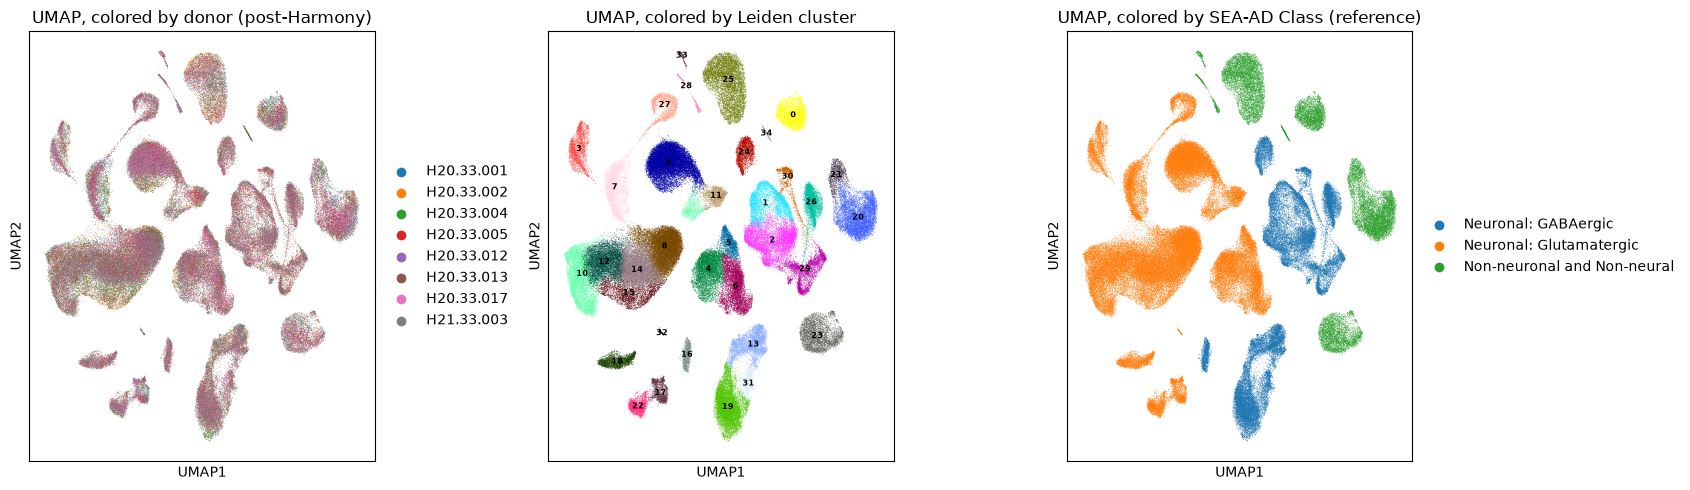

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sc.pl.umap(adata, color="donor", ax=axes[0], show=False, title="UMAP, colored by donor (post-Harmony)")
sc.pl.umap(adata, color="leiden", ax=axes[1], show=False, title="UMAP, colored by Leiden cluster", legend_loc="on data", legend_fontsize=6)
sc.pl.umap(adata, color="Class", ax=axes[2], show=False, title="UMAP, colored by SEA-AD Class (reference)")
plt.tight_layout()
plt.show()

Compare the middle panel (our own unsupervised Leiden clusters) against the
right panel (SEA-AD's independently-derived reference `Class` labels,
which we never used as an input to clustering). If the pipeline worked,
Leiden clusters should respect the same broad boundaries as the reference
classes, even splitting some of them further into finer subtypes — we'll
check this quantitatively with marker genes in notebook 03.

## Saving the processed object

Clustering ~150k nuclei takes real time and memory — we don't want to redo
it from scratch in every following notebook. We save the processed
(HVG-subset, scaled, PCA/Harmony/UMAP/Leiden-annotated) object to
`data/processed/`, which notebooks 03 and 04 will load directly.

In [12]:
import os

os.makedirs(PROCESSED_DIR, exist_ok=True)
out_path = f"{PROCESSED_DIR}/adata_clustered.h5ad"
adata.write_h5ad(out_path)
print(f"Saved: {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")

Saved: /Users/ugobruzadinnunes/Documents/GitHub/sea-ad-python-scanpy/data/processed/adata_clustered.h5ad
File size: 9899.2 MB


## Recap

- Normalized total counts + log-transformed to make nuclei comparable and
  the data closer to normally distributed.
- Selected 2,000 highly variable genes (batch-aware) to focus PCA on
  biologically informative variance.
- Scaled + ran PCA — and **saw a real donor batch effect** in the raw PCA
  embedding.
- Corrected it with Harmony, then clustered the corrected embedding with
  Leiden and visualized with UMAP.
- Saved the result so we don't need to recompute this pipeline in every
  subsequent notebook.

Next: **03_marker_genes_annotation.ipynb** — figure out what cell type each
Leiden cluster actually is, using canonical marker genes, and validate
against SEA-AD's reference labels.

## Homework

1. **Resolution sweep.** Re-run `sc.tl.leiden` with `resolution=0.5` and
   again with `resolution=2.0` (use different `key_added` values so you
   don't overwrite the original). How does the number of clusters change?
   In your own words, what does the "resolution" parameter control?

2. **Skip Harmony.** Recompute neighbors/UMAP using `use_rep="X_pca"`
   (the *uncorrected* PCA) instead of `"X_pca_harmony"`. Plot the resulting
   UMAP colored by `donor`. Does the batch effect reappear? Describe what
   you see compared to the corrected version.

3. **Interpretation.** Look at the per-cluster nuclei counts you printed
   above (`adata.obs["leiden"].value_counts()`). Are all clusters
   reasonably donor-mixed, or does any single cluster look like it's
   dominated by just one or two donors? (Hint: use
   `pd.crosstab(adata.obs["leiden"], adata.obs["donor"])`.) What would a
   donor-dominated cluster suggest?

4. **Write the code yourself:** using `pd.crosstab`, cross-tabulate Leiden
   cluster vs. SEA-AD `Class`. Which Leiden clusters are "pure" (almost
   entirely one Class) and which look mixed?

In [13]:
# Q1 — your code here

In [14]:
# Q2 — your code here

Q3 — your answer here

In [15]:
# Q4 — your code here